# WAV2HYP catalog explorer

Set **`CONFIG_FILE`** / **`CONFIG_PATH`** (and optional path overrides) in **Setup**, then run **Catalog** (defines `catalog_df`, `CATALOG_T1`/`T2`, histogram). Figures and clipboards resolve under **`notebooks/<volcano>/`** (from the config filename). **Catalog** and **Day** use **VolcanoFigure**; **Event** uses **Map** + **CrossSection** + clipboards via `wav2hyp.viz.sthelens_clipboards` (same code as `analysis_local/sthelens_map_and_clipboards.py`).


In [1]:
from __future__ import annotations

from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml
from IPython.display import Image, display

from wav2hyp.config_loader import config_path_anchor
from wav2hyp.utils.io import NLLOutput
from wav2hyp.viz.sthelens_clipboards import (
    attach_pick_probabilities,
    make_catalog_volcano_figure,
    render_single_event_combined_pil,
    sthelens_paths_from_wav2hyp_config,
)


## Setup

Run the next two cells after editing paths. Notebook outputs (maps, clipboards) default to **`notebooks/<volcano>/`**, where **`<volcano>`** is the config filename without extension (e.g. `papandayan.yaml` → `notebooks/papandayan/`).


In [2]:
CONFIG_FILE = "examples_local/papandayan.yaml"

# Path to your WAV2HYP YAML (inventory + output layout).
# Works whether the notebook's working directory is the repo root or notebooks/.
_cwd = Path.cwd()
if (_cwd / CONFIG_FILE).is_file():
    CONFIG_PATH = (_cwd / CONFIG_FILE).resolve()
elif (_cwd.parent / CONFIG_FILE).is_file():
    CONFIG_PATH = (_cwd.parent / CONFIG_FILE).resolve()
else:
    CONFIG_PATH = (_cwd / CONFIG_FILE).resolve()

# <volcano> = config filename stem, e.g. papandayan.yaml -> notebooks/papandayan/
VOLCANO_SLUG = CONFIG_PATH.stem
if (_cwd / "notebooks").is_dir():
    _notebooks_root = _cwd / "notebooks"
elif (_cwd.parent / "notebooks").is_dir():
    _notebooks_root = _cwd.parent / "notebooks"
else:
    _notebooks_root = _cwd / "notebooks"
NOTEBOOK_OUTPUT_DIR = (_notebooks_root / VOLCANO_SLUG).resolve()

# Pipeline output root: must contain locations/nll.h5 unless you set LOCATOR_H5 below.
# If None, uses output.base_dir from the YAML (relative to the YAML file's directory).
RUN_BASE_DIR = None

# Notebook outputs (maps, clipboards): defaults to notebooks/<volcano>/ (see NOTEBOOK_OUTPUT_DIR).
ARTIFACTS_DIR = None

# Set to an explicit nll.h5 path if the catalog file is not under RUN_BASE_DIR/locations/.
LOCATOR_H5 = None

# Optional pre-rendered catalog map filename inside ARTIFACTS_DIR; None -> f"{VOLCANO_SLUG}_map.png"
CATALOG_MAP_PNG_NAME = None
CLIPBOARDS_SUBDIR = "clipboards"


In [3]:
with open(CONFIG_PATH) as f:
    _cfg = yaml.safe_load(f)

NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# output.base_dir and inventory paths in YAML are relative to the repo root (pyproject.toml), not the YAML folder.
if RUN_BASE_DIR is None:
    RUN_BASE_DIR = (config_path_anchor(CONFIG_PATH) / _cfg["output"]["base_dir"]).resolve()
else:
    RUN_BASE_DIR = Path(RUN_BASE_DIR).resolve()

ARTIFACTS_DIR = Path(ARTIFACTS_DIR).resolve() if ARTIFACTS_DIR is not None else NOTEBOOK_OUTPUT_DIR
CATALOG_MAP_PNG_NAME = CATALOG_MAP_PNG_NAME or f"{VOLCANO_SLUG}_map.png"
loc_sub = _cfg["output"].get("locator_dir", "locations")
LOCATOR_H5 = Path(LOCATOR_H5).resolve() if LOCATOR_H5 is not None else (RUN_BASE_DIR / loc_sub / "nll.h5")

_paths = sthelens_paths_from_wav2hyp_config(_cfg, config_path=CONFIG_PATH, run_base_dir=RUN_BASE_DIR)
paths = replace(_paths, nll_h5=Path(LOCATOR_H5).resolve())
INVENTORY_PATH = paths.inventory_path

nll = NLLOutput(str(LOCATOR_H5))

print("CONFIG_PATH          ", CONFIG_PATH)
print("VOLCANO_SLUG         ", VOLCANO_SLUG)
print("NOTEBOOK_OUTPUT_DIR  ", NOTEBOOK_OUTPUT_DIR)
print("RUN_BASE_DIR         ", RUN_BASE_DIR)
print("ARTIFACTS_DIR        ", ARTIFACTS_DIR)
print("CATALOG_MAP_PNG_NAME ", CATALOG_MAP_PNG_NAME)
print("INVENTORY_PATH       ", INVENTORY_PATH)
print("LOCATOR_H5           ", LOCATOR_H5, "exists:", LOCATOR_H5.exists())
print("VolcanoFigure, Map, CrossSection — catalog map uses VolcanoFigure; per-event stacks use Map + CrossSection in wav2hyp.viz.sthelens_clipboards.")
print("Run the Catalog cell to load catalog_df (time-filtered) and figures.")


CONFIG_PATH           /home/jwellik/PYTHON/PKG/wav2hyp/examples_local/papandayan.yaml
VOLCANO_SLUG          papandayan
NOTEBOOK_OUTPUT_DIR   /home/jwellik/PYTHON/PKG/wav2hyp/notebooks/papandayan
RUN_BASE_DIR          /home/jwellik/PYTHON/PKG/wav2hyp/results_local/papandayan
ARTIFACTS_DIR         /home/jwellik/PYTHON/PKG/wav2hyp/notebooks/papandayan
CATALOG_MAP_PNG_NAME  papandayan_map.png
INVENTORY_PATH        /home/jwellik/PYTHON/PKG/wav2hyp/examples_local/papandayan_inventory.xml
LOCATOR_H5            /home/jwellik/PYTHON/PKG/wav2hyp/results_local/papandayan/3_locations/nll.h5 exists: True
VolcanoFigure, Map, CrossSection — catalog map uses VolcanoFigure; per-event stacks use Map + CrossSection in wav2hyp.viz.sthelens_clipboards.
Run the Catalog cell to load catalog_df (time-filtered) and figures.


## Catalog

Set **`CATALOG_T1`** / **`CATALOG_T2`** (same strings you would pass to CLI ``--t1`` / ``--t2``; `None` = full file). Set **`HISTOGRAM_FREQ`** (pandas offset: ``"1D"``, ``"1h"``, …). Then run the code cell: **VolcanoFigure** overview map, histogram, and optional saved PNG.


catalog_df rows: 14


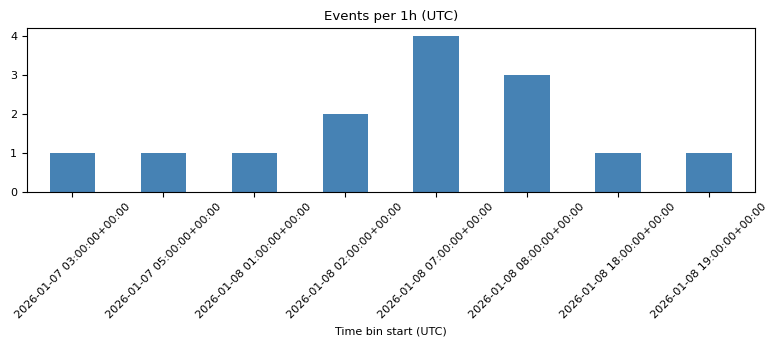

/home/jwellik/miniconda3/envs/wav2hyp/lib/python3.12/site-packages/shapely/ops.py:259: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  shell = type(geom.exterior)(zip(*func(*zip(*geom.exterior.coords))))
/home/jwellik/miniconda3/envs/wav2hyp/lib/python3.12/site-packages/shapely/ops.py:259: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  shell = type(geom.exterior)(zip(*func(*zip(*geom.exterior.coords))))


Terrain tiles failed: add_arcgis_terrain() got an unexpected keyword argument 'style'
Failed to add hillshade via PyGMT: Error loading GMT shared library at 'libgmt.so'.
libgmt.so: cannot open shared object file: No such file or directory
Continuing without hillshade...
Error plotting inventory: cartopy.mpl.geoaxes.GeoAxes.scatter() got multiple values for keyword argument 's'
Continuing without inventory plot...
Error plotting inventory on cross-section: matplotlib.axes._axes.Axes.scatter() got multiple values for keyword argument 's'
Continuing without cross-section inventory plot...
Error plotting inventory on cross-section: matplotlib.axes._axes.Axes.scatter() got multiple values for keyword argument 's'
Continuing without cross-section inventory plot...
No optional pre-rendered map PNG at /home/jwellik/PYTHON/PKG/wav2hyp/notebooks/papandayan/papandayan_map.png


/home/jwellik/miniconda3/envs/wav2hyp/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1677: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  result = super().scatter(*args, **kwargs)
/home/jwellik/miniconda3/envs/wav2hyp/lib/python3.12/site-packages/vdapseisutils/core/maps/maps.py:1522: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = self.ax.scatter(x, catdata["depth"], s=s, c=c, cmap=cmap, alpha=alpha, **kwargs)
/home/jwellik/miniconda3/envs/wav2hyp/lib/python3.12/site-packages/vdapseisutils/core/maps/maps.py:1522: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = self.ax.scatter(x, catdata["depth"], s=s, c=c, cmap=cmap, alpha=alpha, **kwargs)


In [5]:
# Time window on catalog_table (None = no bound). Strings are passed to NLLOutput / ObsPy UTCDateTime.
CATALOG_T1 = None  # e.g. "2004-09-23T00:00:00"
CATALOG_T2 = None  # e.g. "2004-09-24T00:00:00"

# Histogram bin width: pandas offset alias, e.g. "1D" (daily), "1h", "6h", "7D"
HISTOGRAM_FREQ = "1h"

catalog_df = nll.read_catalog_table(t1=CATALOG_T1, t2=CATALOG_T2)
print(f"catalog_df rows: {len(catalog_df)}")

cat = catalog_df.copy()
cat["origin_time"] = pd.to_datetime(cat["origin_time"], utc=True, errors="coerce")
_freq = HISTOGRAM_FREQ.strip()
if _freq.lower() in ("1d", "d"):
    _freq = "1D"

# Event rate (NLL located): step plot + axis styling aligned with analysis_local/spurr_analysis.ipynb
from obspy.imaging.util import _set_xaxis_obspy_dates

from wav2hyp.viz.plot_styles import NLL_CATALOG_COLOR, apply_mpl_axes_style

if len(cat) > 0:
    rate = pd.Series(1, index=cat["origin_time"]).resample(_freq).sum().fillna(0)
    if rate.sum() > 0:
        fig, axh = plt.subplots(1, 1, figsize=(14, 4.5))
        apply_mpl_axes_style(axh)
        axh.step(
            rate.index,
            rate.values,
            where="post",
            lw=2,
            color=NLL_CATALOG_COLOR,
            label="NLL (located)",
        )
        _set_xaxis_obspy_dates(axh)
        axh.set_ylabel(f"Events per {_freq}")
        axh.set_xlabel("Time")
        axh.legend(loc="upper left")
        plt.tight_layout()
        plt.show()
    else:
        print("No events in histogram range (empty catalog or no data in time window).")
else:
    print("No events in histogram range (empty catalog or no data in time window).")

if len(cat) > 0:
    _ = make_catalog_volcano_figure(
        _cfg,
        cat,
        inventory_path=paths.inventory_path,
        map_t1=CATALOG_T1,
        map_t2=CATALOG_T2,
        out_png=None,
    )
    plt.show()
else:
    print("Skipping VolcanoFigure (empty catalog).")

_map = ARTIFACTS_DIR / CATALOG_MAP_PNG_NAME
if _map.is_file():
    display(Image(filename=str(_map)))
else:
    print(f"No optional pre-rendered map PNG at {_map}")


## Day view

Pick a **UTC calendar date** that overlaps your origins.


In [6]:
# VIEW_DATE = "2004-09-23"  # St. Helens
VIEW_DATE = "2026-01-08"  # Papandayan


In [7]:
day_start = pd.Timestamp(VIEW_DATE, tz="UTC")
day_end = day_start + pd.Timedelta(days=1)
day_df = catalog_df[
    (pd.to_datetime(catalog_df["origin_time"], utc=True) >= day_start)
    & (pd.to_datetime(catalog_df["origin_time"], utc=True) < day_end)
].copy()

display(day_df)

day_t1 = day_start.strftime("%Y-%m-%dT%H:%M:%S")
day_t2 = day_end.strftime("%Y-%m-%dT%H:%M:%S")
make_catalog_volcano_figure(
    _cfg,
    day_df,
    inventory_path=paths.inventory_path,
    map_t1=day_t1,
    map_t2=day_t2,
    out_png=None,
)
plt.show()


,event_id,origin_time,latitude,longitude,depth_km,x,y,z,mag,mag_type,residual_rms,n_picks,n_p_picks,n_s_picks,azimuthal_gap,creation_info,comments
2,smi:local/e97b4c0e-0ab3-498d-b44a-ce90c109be7f,2026-01-08 02:59:31.888849+00:00,-7.418885,107.744636,-4.938210,NaN,NaN,NaN,NaN,,0.078468,10,5,5,333.750,"{""author"": ""USGS Volcano Disaster Assistance P...","[{""text"": ""Note: Depth/Latitude/Longitude erro..."
3,smi:local/f80611fd-7bef-4664-b4a4-f2cb65e09d38,2026-01-08 07:46:58.027968+00:00,-7.309083,107.725021,-4.526278,NaN,NaN,NaN,NaN,,0.045910,11,5,6,259.155,"{""author"": ""USGS Volcano Disaster Assistance P...","[{""text"": ""Note: Depth/Latitude/Longitude erro..."
4,smi:local/739b8e77-5b11-4ced-86a8-243455558f09,2026-01-08 07:55:42.141049+00:00,-7.313978,107.694902,-818.892000,NaN,NaN,NaN,NaN,,0.050670,10,5,5,336.140,"{""author"": ""USGS Volcano Disaster Assistance P...","[{""text"": ""Note: Depth/Latitude/Longitude erro..."
5,smi:local/406d6611-5cdc-4ddf-b2f4-130c0e23f7f9,2026-01-08 02:32:10.937207+00:00,-7.316776,107.714514,-4.979403,NaN,NaN,NaN,NaN,,0.049535,10,5,5,311.807,"{""author"": ""USGS Volcano Disaster Assistance P...","[{""text"": ""Note: Depth/Latitude/Longitude erro..."
6,smi:local/20f90abb-f003-47e8-8179-f59f4f4a4fa8,2026-01-08 01:51:14.879049+00:00,-7.313279,107.712413,-4.979403,NaN,NaN,NaN,NaN,,0.040896,10,5,5,316.035,"{""author"": ""USGS Volcano Disaster Assistance P...","[{""text"": ""Note: Depth/Latitude/Longitude erro..."
7,smi:local/f6a1c572-418d-4198-8302-3b438a534cfd,2026-01-08 08:00:16.754723+00:00,-7.311880,107.706809,-4.114347,NaN,NaN,NaN,NaN,,0.064750,10,5,5,323.821,"{""author"": ""USGS Volcano Disaster Assistance P...","[{""text"": ""Note: Depth/Latitude/Longitude erro..."
8,smi:local/259dcd37-97ce-4509-88c3-054c8b3be74c,2026-01-08 08:04:21.997573+00:00,-7.313629,107.700855,1.426136,NaN,NaN,NaN,NaN,,25.813000,10,5,5,331.708,"{""author"": ""USGS Volcano Disaster Assistance P...","[{""text"": ""Note: Depth/Latitude/Longitude erro..."
9,smi:local/f2eb3d85-ce3e-4e5d-a0a8-cd6f22bca11e,2026-01-08 08:02:01.769032+00:00,-7.311181,107.715915,-4.691051,NaN,NaN,NaN,NaN,,0.045223,10,5,5,303.901,"{""author"": ""USGS Volcano Disaster Assistance P...","[{""text"": ""Note: Depth/Latitude/Longitude erro..."
10,smi:local/4e90bbe2-5700-4483-a81c-9281406463e5,2026-01-08 07:53:02.355962+00:00,-7.326567,107.711012,-4.031960,NaN,NaN,NaN,NaN,,0.023324,10,5,5,327.979,"{""author"": ""USGS Volcano Disaster Assistance P...","[{""text"": ""Note: Depth/Latitude/Longitude erro..."
11,smi:local/ca6af74c-5e10-4b72-8d2e-18132bfe866e,2026-01-08 18:08:11.643262+00:00,-7.334610,107.755491,3.815341,NaN,NaN,NaN,NaN,,9.615740,12,6,6,315.918,"{""author"": ""USGS Volcano Disaster Assistance P...","[{""text"": ""Note: Depth/Latitude/Longitude erro..."


/home/jwellik/miniconda3/envs/wav2hyp/lib/python3.12/site-packages/shapely/ops.py:259: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  shell = type(geom.exterior)(zip(*func(*zip(*geom.exterior.coords))))
/home/jwellik/miniconda3/envs/wav2hyp/lib/python3.12/site-packages/shapely/ops.py:259: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  shell = type(geom.exterior)(zip(*func(*zip(*geom.exterior.coords))))


Terrain tiles failed: add_arcgis_terrain() got an unexpected keyword argument 'style'
Failed to add hillshade via PyGMT: Error loading GMT shared library at 'libgmt.so'.
libgmt.so: cannot open shared object file: No such file or directory
Continuing without hillshade...
Error plotting inventory: cartopy.mpl.geoaxes.GeoAxes.scatter() got multiple values for keyword argument 's'
Continuing without inventory plot...
Error plotting inventory on cross-section: matplotlib.axes._axes.Axes.scatter() got multiple values for keyword argument 's'
Continuing without cross-section inventory plot...
Error plotting inventory on cross-section: matplotlib.axes._axes.Axes.scatter() got multiple values for keyword argument 's'
Continuing without cross-section inventory plot...


/home/jwellik/miniconda3/envs/wav2hyp/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1677: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  result = super().scatter(*args, **kwargs)
/home/jwellik/miniconda3/envs/wav2hyp/lib/python3.12/site-packages/vdapseisutils/core/maps/maps.py:1522: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = self.ax.scatter(x, catdata["depth"], s=s, c=c, cmap=cmap, alpha=alpha, **kwargs)
/home/jwellik/miniconda3/envs/wav2hyp/lib/python3.12/site-packages/vdapseisutils/core/maps/maps.py:1522: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = self.ax.scatter(x, catdata["depth"], s=s, c=c, cmap=cmap, alpha=alpha, **kwargs)


## Event view

Set **`EVENT_ID`** to the full `event_id` from `catalog_table`. The cell below builds the stacked figure (``Map`` + ``CrossSection`` + waveforms + tables) using :func:`wav2hyp.viz.sthelens_clipboards.render_single_event_combined_pil` — same pipeline as ``analysis_local/sthelens_map_and_clipboards.py``. Requires SDS waveform access from your YAML. Falls back to disk images under **`ARTIFACTS_DIR / CLIPBOARDS_SUBDIR`** if rendering returns nothing.


In [8]:
EVENT_ID = "smi:local/f6a1c572-418d-4198-8302-3b438a534cfd"
# If clipboard PNG names do not include the full EVENT_ID, set a substring that appears in the filename (e.g. short hash).
CLIPBOARD_NAME_SUBSTRING = None


,event_id,origin_time,latitude,longitude,depth_km,x,y,z,mag,mag_type,residual_rms,n_picks,n_p_picks,n_s_picks,azimuthal_gap,creation_info,comments
7,smi:local/f6a1c572-418d-4198-8302-3b438a534cfd,2026-01-08 08:00:16.754723+00:00,-7.31188,107.706809,-4.114347,NaN,NaN,NaN,NaN,,0.06475,10,5,5,323.821,"{""author"": ""USGS Volcano Disaster Assistance P...","[{""text"": ""Note: Depth/Latitude/Longitude erro..."


  Pick probability join (eqt-volpick): 10/10 arrivals matched (nearest peak within 2s, same station & P/S)


,event_id,origin_time,trace_id,station_id,phase,pick_id,arrival_time,residual,weight,residual_uncert,weight_uncert,creation_info,comments,prob,_sta
0,smi:local/f6a1c572-418d-4198-8302-3b438a534cfd,2026-01-08 08:00:16.754723+00:00,.PPNK..Z,.PPNK,P,smi:local/6759aa41-5477-487a-ba4a-ef5ff11a5bc6,2026-01-08 08:00:17.540000+00:00,-0.1692,0.4659,NaN,NaN,{},[],0.829925,PPNK
1,smi:local/f6a1c572-418d-4198-8302-3b438a534cfd,2026-01-08 08:00:16.754723+00:00,.PPKB..Z,.PPKB,P,smi:local/45757843-eb08-462b-8198-da59bb08b8d0,2026-01-08 08:00:17.630000+00:00,-0.3453,0.0149,NaN,NaN,{},[],0.826524,PPKB
2,smi:local/f6a1c572-418d-4198-8302-3b438a534cfd,2026-01-08 08:00:16.754723+00:00,.PPTP..Z,.PPTP,P,smi:local/00a556cd-5f96-4de7-810d-95e545a8d614,2026-01-08 08:00:17.660000+00:00,-0.0175,1.3958,NaN,NaN,{},[],0.854118,PPTP
3,smi:local/f6a1c572-418d-4198-8302-3b438a534cfd,2026-01-08 08:00:16.754723+00:00,.PPWG..Z,.PPWG,P,smi:local/3db9a6aa-6dac-4fe5-9145-7c2d2b92acdf,2026-01-08 08:00:17.920000+00:00,-0.0525,1.2754,NaN,NaN,{},[],0.679341,PPWG
4,smi:local/f6a1c572-418d-4198-8302-3b438a534cfd,2026-01-08 08:00:16.754723+00:00,.PPPH..Z,.PPPH,P,smi:local/1fb29a5a-c4b3-41d4-ba2c-53efa7bbef28,2026-01-08 08:00:18.190000+00:00,0.0499,1.0533,NaN,NaN,{},[],0.821057,PPPH
5,smi:local/f6a1c572-418d-4198-8302-3b438a534cfd,2026-01-08 08:00:16.754723+00:00,.PPTP..N,.PPTP,S,smi:local/0046ed97-3ea7-4564-a0e4-168048e30199,2026-01-08 08:00:18.280000+00:00,-0.0711,1.1621,NaN,NaN,{},[],0.580217,PPTP
6,smi:local/f6a1c572-418d-4198-8302-3b438a534cfd,2026-01-08 08:00:16.754723+00:00,.PPNK..N,.PPNK,S,smi:local/27ca73b6-6752-4d80-97ba-ae88b34d846a,2026-01-08 08:00:18.410000+00:00,0.0040,1.3753,NaN,NaN,{},[],0.482793,PPNK
7,smi:local/f6a1c572-418d-4198-8302-3b438a534cfd,2026-01-08 08:00:16.754723+00:00,.PPWG..N,.PPWG,S,smi:local/a0ba9c4b-c2c5-4d28-ae31-dc5c220535bc,2026-01-08 08:00:18.730000+00:00,-0.1315,0.7294,NaN,NaN,{},[],0.426463,PPWG
8,smi:local/f6a1c572-418d-4198-8302-3b438a534cfd,2026-01-08 08:00:16.754723+00:00,.PPKB..N,.PPKB,S,smi:local/964f5968-4134-4d9c-9bab-202a632f793b,2026-01-08 08:00:18.890000+00:00,0.0237,1.2809,NaN,NaN,{},[],0.426316,PPKB
9,smi:local/f6a1c572-418d-4198-8302-3b438a534cfd,2026-01-08 08:00:16.754723+00:00,.PPPH..N,.PPPH,S,smi:local/7904a3ce-e99f-443a-a66a-ac6f155eb10a,2026-01-08 08:00:19.180000+00:00,0.0285,1.2469,NaN,NaN,{},[],0.676365,PPPH


/home/jwellik/miniconda3/envs/wav2hyp/lib/python3.12/site-packages/shapely/ops.py:259: FutureWarning: This function is deprecated. See: https://pyproj4.github.io/pyproj/stable/gotchas.html#upgrading-to-pyproj-2-from-pyproj-1
  shell = type(geom.exterior)(zip(*func(*zip(*geom.exterior.coords))))


Failed to add hillshade via PyGMT: Error loading GMT shared library at 'libgmt.so'.
libgmt.so: cannot open shared object file: No such file or directory
Continuing without hillshade...
    scatter cloud failed: module 'nllpy' has no attribute 'read_scat'


/home/jwellik/miniconda3/envs/wav2hyp/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1677: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  result = super().scatter(*args, **kwargs)
/home/jwellik/miniconda3/envs/wav2hyp/lib/python3.12/site-packages/vdapseisutils/core/maps/cross_section.py:298: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  return self.ax.scatter(x, depth, **kwargs)
/home/jwellik/miniconda3/envs/wav2hyp/lib/python3.12/site-packages/vdapseisutils/core/maps/cross_section.py:298: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  return self.ax.scatter(x, depth, **kwargs)


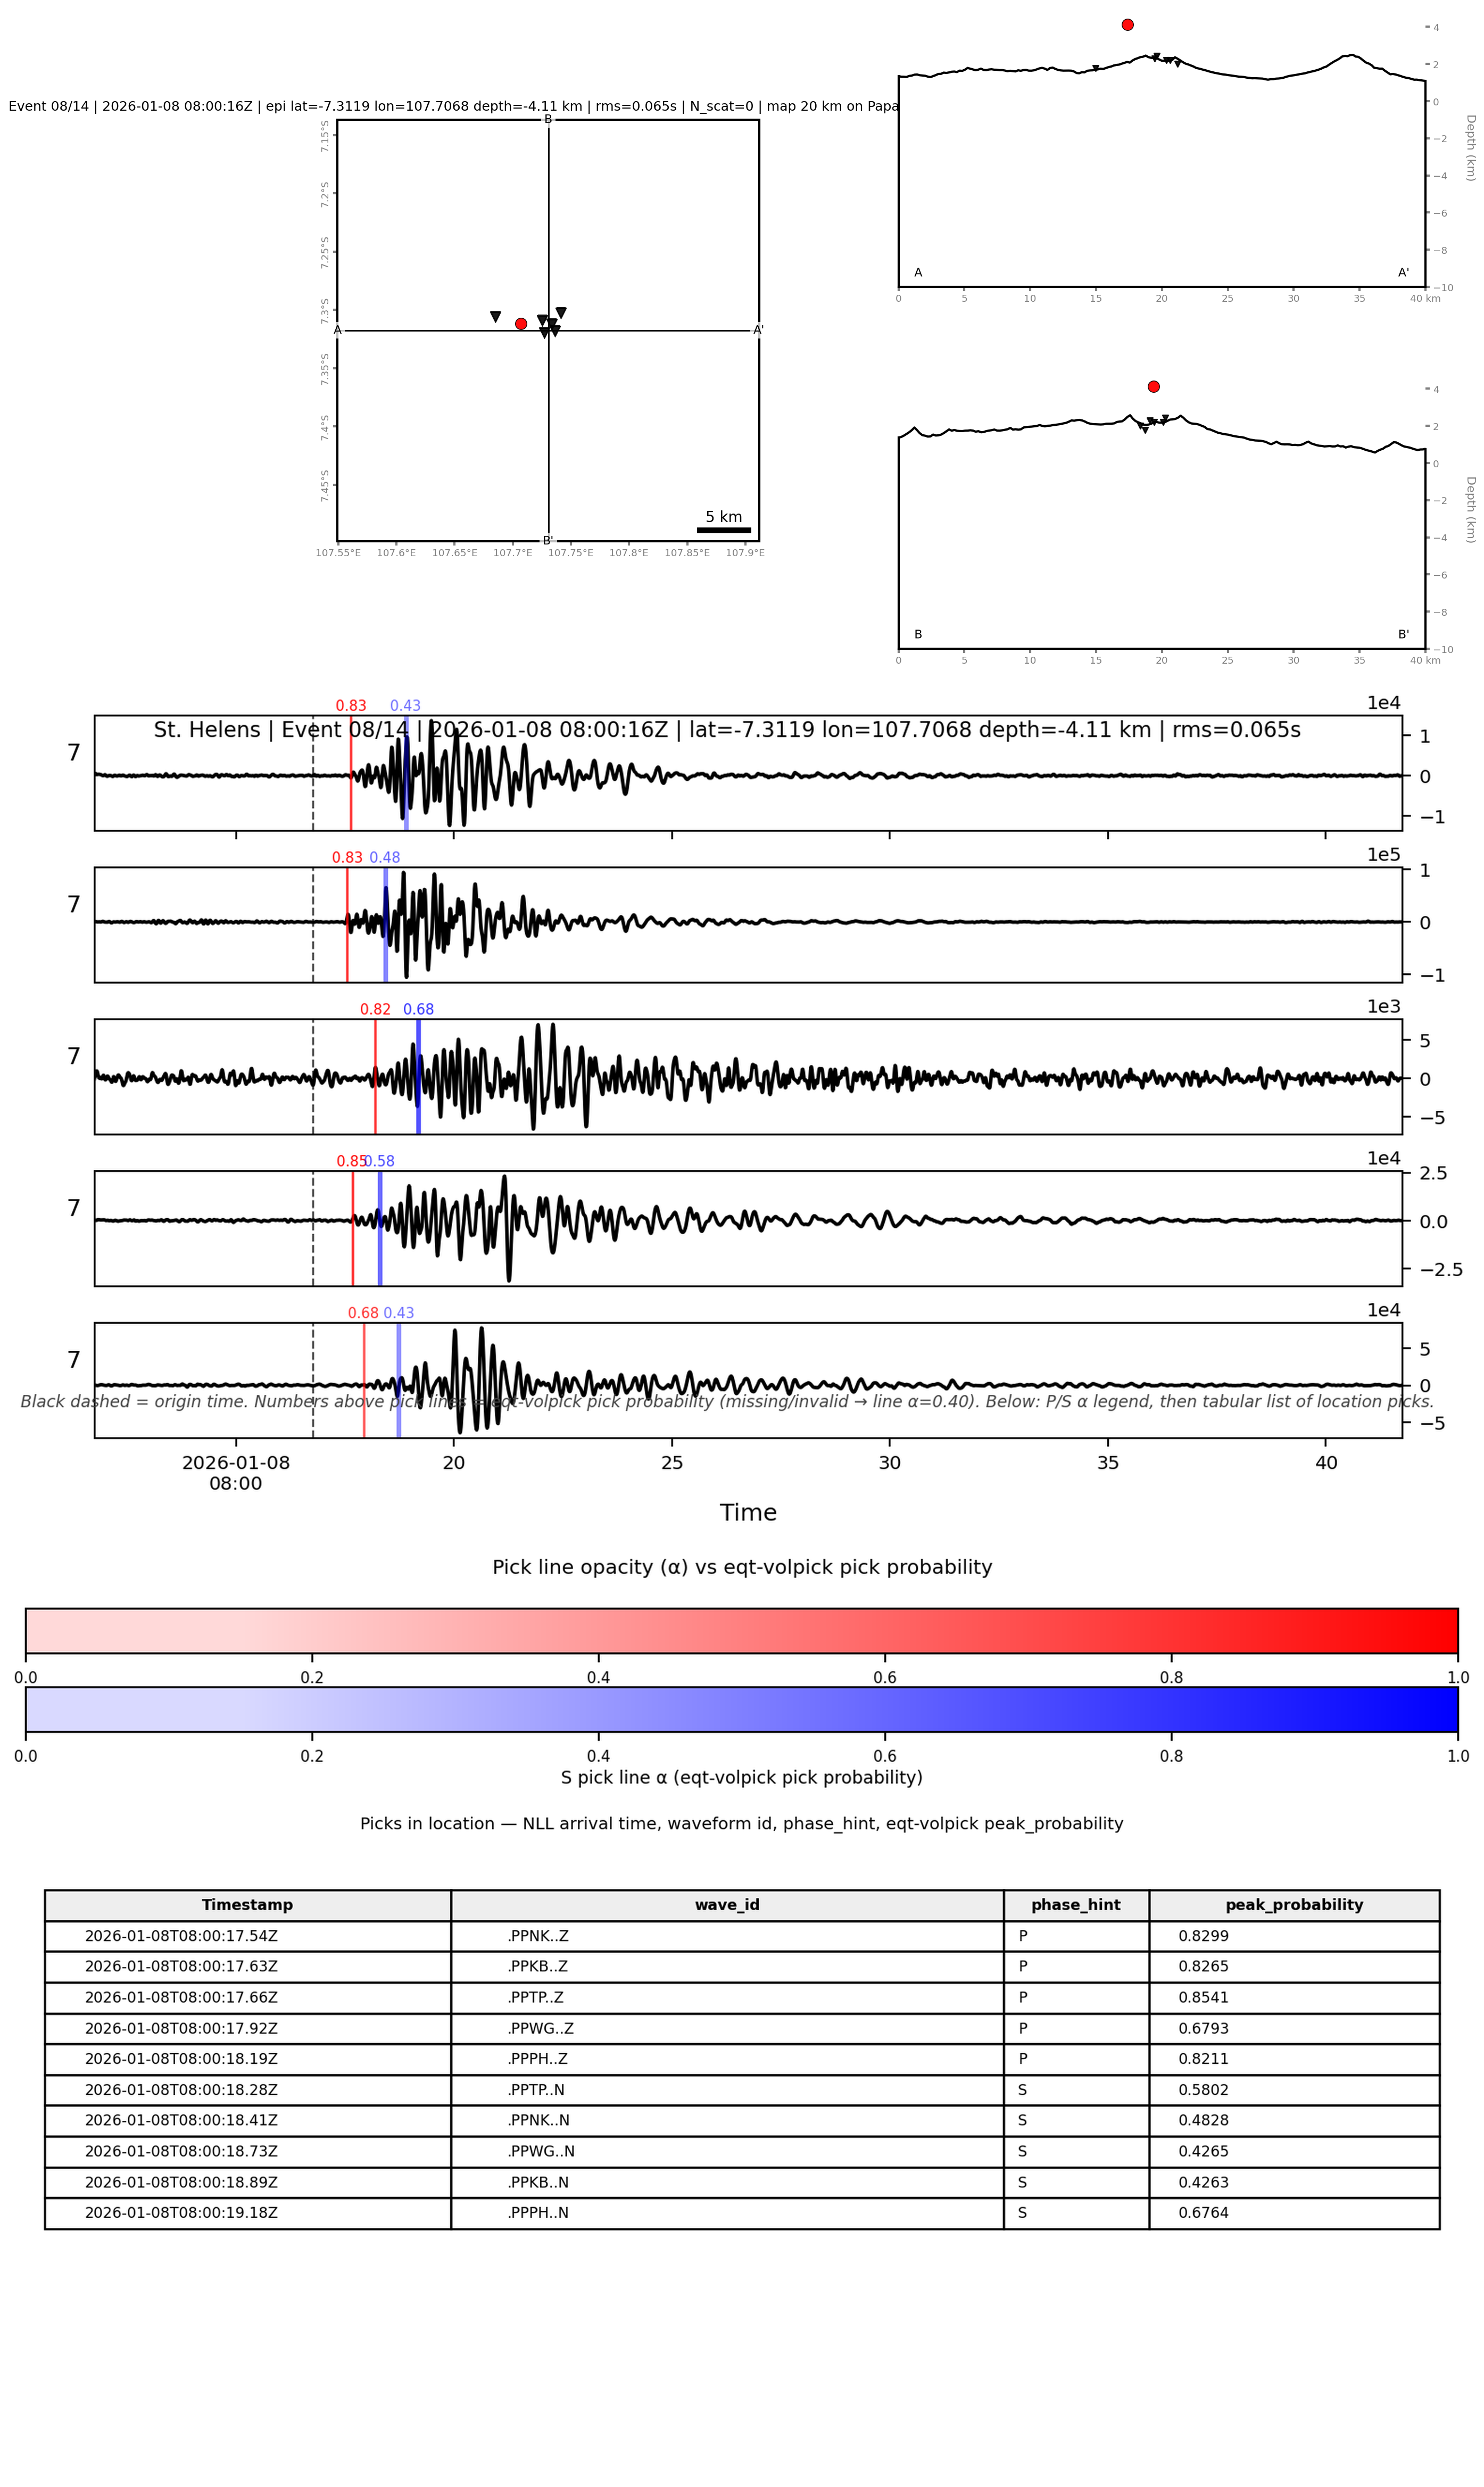

No clipboards directory at /home/jwellik/PYTHON/PKG/wav2hyp/notebooks/papandayan/clipboards (optional)


In [9]:
ev_df = catalog_df.loc[catalog_df["event_id"].astype(str) == str(EVENT_ID)]
display(ev_df)

if len(ev_df) == 1:
    arr = nll.read_arrivals(event_ids=[str(EVENT_ID)])
    arr = attach_pick_probabilities(
        catalog_df,
        arr,
        eqt_volpick_h5=paths.eqt_volpick_h5,
        t1=CATALOG_T1,
        t2=CATALOG_T2,
    )
    display(arr)
    pil_img = render_single_event_combined_pil(
        _cfg, paths, catalog_df, arr, event_id=str(EVENT_ID)
    )
    if pil_img is not None:
        display(pil_img)
    else:
        print("render_single_event_combined_pil returned None (no waveforms or missing event).")
else:
    print("No single match — check EVENT_ID against the catalog table.")

_clip = ARTIFACTS_DIR / CLIPBOARDS_SUBDIR
_placeholder = "paste-full-event_id-here"
_needle = CLIPBOARD_NAME_SUBSTRING or (None if EVENT_ID == _placeholder else EVENT_ID)
if _clip.is_dir() and _needle:
    hits = sorted(p for p in _clip.iterdir() if _needle in p.name)
    for p in hits:
        if p.suffix.lower() in {".png", ".jpg", ".jpeg", ".gif", ".webp"}:
            display(Image(filename=str(p)))
    if not hits:
        print(f"No clipboard files under {_clip} with {_needle!r} in the name.")
elif _clip.is_dir():
    print("Set EVENT_ID (and CLIPBOARD_NAME_SUBSTRING if needed) to search clipboards.")
else:
    print(f"No clipboards directory at {_clip} (optional)")
